# 01 · Synthetic Data Generation

**Project:** Vehicle Service Operations Analytics & Process Optimization
**Purpose of this notebook:** explain *how* the synthetic service-operations dataset is produced, prove that it is
reproducible, and profile the raw extract before any cleaning.

> **Synthetic data disclaimer.** The dataset simulates an EV two-wheeler after-sales network modelled on the
> Ather 450X, Ather 450 Apex and Ather Rizta product line. Every customer, vehicle, technician, price and
> operational figure is invented. The project is **not affiliated with, endorsed by, or based on data from Ather Energy**.

**Contents**
1. Design of the simulated network (centres, models, service types, parts)
2. Simulation logic - how operational patterns *emerge* rather than being hard-coded into outputs
3. Injected data-entry defects and the generation manifest
4. Reproducibility check - regenerate in memory and compare with `data/raw`
5. Raw-data profile - schema, nulls, duplicates, distributions

In [1]:
# Locate the project root (folder containing src/ and data/) so the notebook runs from anywhere.
import os, sys
from pathlib import Path

_here = Path.cwd().resolve()
ROOT = next(p for p in [_here, *_here.parents] if (p / "src").is_dir() and (p / "data").is_dir())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: C:\Vehicle_Service_Operations_Analytics


In [2]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.reference_data import (BOOKING_CHANNELS, CENTRES, MODEL_SHARE, MODELS, PARTS, REPAIR_MIX,
                                SERVICE_TYPES, SKILL_LEVELS, STOCKOUT_BASE)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
print("Reporting period:", config.PERIOD_START, "to", config.PERIOD_END, "| seed:", config.SEED)

Reporting period: 2025-01-01 to 2026-09-30 | seed: 42


## 1. Design of the simulated network

### 1.1 Service centres
Eight centres across four regions. Each centre has fixed parameters that act as the *hidden* operational
levers the analysis later has to rediscover from the data alone:

| Lever | Meaning |
|---|---|
| `demand_weight` | relative share of customers whose home centre this is |
| `technicians` | rostered technicians (capacity) |
| `parts_risk` | multiplier on stock-out probability (supply-chain distance from the parts hub) |
| `extra_lead_days` | additional booking lead time when slots are scarce |
| `junior_heavy_roster` | roster staffed mainly by junior technicians |

Only the columns a real centre master would hold (`service_bays`, `daily_job_capacity`, `opened_date`, ...)
are written to `service_centers.csv`; the simulation levers are **not** exported.

In [3]:
centres = pd.DataFrame([c.__dict__ for c in CENTRES])
centres

,center_id,center_name,city,state,region,service_bays,daily_job_capacity,opened_date,demand_weight,technicians,parts_risk,extra_lead_days,junior_heavy_roster
0,C001,Bengaluru - Indiranagar,Bengaluru,Karnataka,South,8,22,2019-06-01,1.50,3,0.8,1.5,False
1,C002,Bengaluru - Whitefield,Bengaluru,Karnataka,South,7,18,2020-02-15,1.25,3,0.8,0.5,False
2,C003,Chennai - Anna Nagar,Chennai,Tamil Nadu,South,6,16,2020-09-01,0.98,2,0.9,0.5,False
3,C004,Hyderabad - Gachibowli,Hyderabad,Telangana,South,6,15,2021-03-10,0.90,2,0.9,0.5,False
4,C005,Pune - Baner,Pune,Maharashtra,West,6,15,2021-07-01,0.82,2,1.0,0.5,False
5,C006,Mumbai - Andheri,Mumbai,Maharashtra,West,5,12,2021-11-15,0.96,2,1.0,4.0,True
6,C007,Delhi - Saket,New Delhi,Delhi,North,6,15,2021-05-01,0.92,2,1.3,0.8,False
7,C008,Kolkata - Salt Lake,Kolkata,West Bengal,East,4,10,2022-09-01,0.82,2,2.8,0.5,False


### 1.2 Vehicle models, service types and parts
* **Models:** Ather 450X (performance, launched 2020), Ather 450 Apex (performance, 2024) and Ather Rizta
  (family, 2024). Fleet customers buy only 450X and Rizta.
* **Service types:** one planned type (*Periodic Service*, roughly every 6 months for individuals, 3 months for
  fleets) and ten unplanned repair types. Four are flagged *complex* (motor/controller, charging, electrical,
  accident) - they favour skilled technicians and have higher rework risk.
* **Parts:** 39 SKUs in 10 categories, each with a unit cost and supplier lead time. Base stock-out
  probability rises with part complexity (consumables 0.4% → dashboard/display 18%).

In [4]:
models = pd.DataFrame([{"model": m, "category": v[0], "launch": v[2], "variants": ", ".join(x[0] for x in v[1]),
                        "sales_share": MODEL_SHARE[m]} for m, v in MODELS.items()])
stypes = pd.DataFrame([{"service_type": s.name, "base_hours": s.base_hours, "complex_job": s.complex_job,
                        "warranty_eligible": s.warranty_eligible, "repair_mix_weight": REPAIR_MIX.get(s.name, "planned"),
                        "candidate_parts": len(s.parts)} for s in SERVICE_TYPES.values()])
parts = pd.DataFrame(PARTS, columns=["part_id", "part_name", "part_category", "unit_cost", "compatible_models", "supplier_lead_days"])
cat = (parts.groupby("part_category").agg(skus=("part_id", "size"), median_unit_cost=("unit_cost", "median"),
                                          mean_lead_days=("supplier_lead_days", "mean"))
       .assign(base_stockout_prob=lambda d: d.index.map(STOCKOUT_BASE)).sort_values("base_stockout_prob"))
skills = pd.DataFrame(SKILL_LEVELS, index=["hourly_cost_inr", "labour_time_multiplier", "extra_qc_fail_prob",
                                           "extra_comeback_prob", "years_range"]).T
display(models, stypes, cat, skills)
print("Booking channel mix:", BOOKING_CHANNELS)

,model,category,launch,variants,sales_share
0,Ather 450X,Performance,2020-01-15,"450X 2.9kWh, 450X 3.7kWh",0.44
1,Ather 450 Apex,Performance,2024-02-01,450 Apex 3.7kWh,0.11
2,Ather Rizta,Family,2024-06-01,"Rizta S 2.9kWh, Rizta Z 2.9kWh, Rizta Z 3.7kWh",0.45


,service_type,base_hours,complex_job,warranty_eligible,repair_mix_weight,candidate_parts
0,Periodic Service,1.50,False,False,planned,6
1,Battery Health Check,1.00,False,True,14,4
2,Software Update Support,0.75,False,False,10,1
3,Brake Service,1.50,False,False,14,4
4,Tyre Replacement,1.00,False,False,12,3
5,Belt Drive Service,2.00,False,False,8,2
6,Motor & Controller Repair,4.00,True,True,5,4
7,Charging System Repair,2.50,True,True,8,4
8,Electrical Diagnostics,2.00,True,True,10,5
9,Suspension Service,2.50,False,False,6,3


,skus,median_unit_cost,mean_lead_days,base_stockout_prob
part_category,,,,
Consumables,3,200.0,1.333333,0.004
Brakes,4,625.0,3.250000,0.020
Tyres,3,1700.0,3.333333,0.030
Drivetrain,2,3050.0,6.500000,0.050
Suspension,3,3100.0,7.000000,0.050
Body & Lighting,6,3050.0,7.666667,0.060
Battery & Electrical,6,4850.0,8.500000,0.080
Charging,4,4550.0,8.000000,0.100
Motor & Controller,5,13200.0,11.200000,0.160


,hourly_cost_inr,labour_time_multiplier,extra_qc_fail_prob,extra_comeback_prob,years_range
Junior,210.0,1.22,0.05,0.03,"(0, 2)"
Mid,280.0,1.06,0.02,0.012,"(2, 5)"
Senior,360.0,0.97,0.0,0.004,"(5, 9)"
Master,450.0,0.9,-0.01,0.0,"(9, 15)"


Booking channel mix: {'Ather App': 0.55, 'Call Centre': 0.2, 'Walk-in': 0.15, 'Website': 0.1}


## 2. Simulation logic

The generator (`src/generate_data.py`) runs a small discrete simulation rather than sampling each output
column independently. That matters: the patterns the analysis finds are *consequences* of capacity, parts
and skill mechanics, the same way they would be in a real workshop.

| Step | What happens | Patterns it creates |
|---|---|---|
| Customers & vehicles | 5,300 vehicles bought between launch and Sep 2026; fleets drive ~80 km/day | Mileage, service-plan uptake, fleet mix |
| Demand | Periodic services follow the service interval (75-88% compliance); repairs arrive as a Poisson process that rises with vehicle age and monsoon months (Jun-Sep) | Seasonality and **~47% YoY growth** as the fleet ages and grows |
| Booking | Channel → lead time; Mumbai has +4 extra lead days (slot scarcity) | Lead time → cancellation (+0.7 pp per lead day), Monday cancellations |
| Day load | Booked estimated hours ÷ (technicians × 7 productive h) for each centre-day | Queue wait rises steeply above 80% load; Saturday peak (1.55× weekday demand) |
| Technician assignment | Complex jobs prefer Senior/Master; simple jobs prefer Junior; busy technicians less likely to be picked | Skill-driven labour overruns, QC failures, comebacks |
| Parts | Each required part can be out of stock (category base × centre `parts_risk` × model factor); the job pauses for the supplier lead time | Long-tail turnaround, Kolkata stock-outs, Apex/Rizta supply effects |
| QC & comebacks | QC first-pass and 30-day comeback probability depend on skill, job complexity and overload | Rework visits billed at zero revenue |
| Billing | Customer-paid labour billed on *estimated* hours at ₹750/h (×1.35 when extra work found), parts +30%; warranty, service-plan and fleet-discount rules | Margin varies by billing type and skill |
| Feedback | Response propensity higher after a bad experience; rating falls with lateness, wait > 1.5 h, comebacks, extra work | Rating ↔ delay relationships |

**Promise rule:** `promised_ready_time = check-in + estimated hours + 1.5 shop hours` (Mon-Sat, 09:00-19:00).
`on_time_flag = end_time <= promised_ready_time` (derived during cleaning).

## 3. Injected data-entry defects

After simulation a small, documented share of realistic data-entry defects is injected so the data-quality
pipeline has something real to detect. The generator writes the exact counts to
`data/raw/generation_manifest.json`; notebook 02 reconciles them against what the cleaning pipeline detects.

In [5]:
manifest = json.loads((config.RAW_DIR / "generation_manifest.json").read_text(encoding="utf-8"))
defects = pd.DataFrame([{"table": t, "defect": k, "rows_injected": v}
                        for t, d in manifest["injected_defects"].items() for k, v in d.items()])
print("Seed:", manifest["seed"], "| Period:", manifest["period"])
print("Total injected defect rows:", defects["rows_injected"].sum())
defects

Seed: 42 | Period: ['2025-01-01', '2026-09-30']
Total injected defect rows: 1431


,table,defect,rows_injected
0,customers,region_format_variants,33
1,customers,duplicate_rows,13
2,vehicles,impossible_model_year,21
3,vehicles,impossible_mileage,15
4,vehicles,model_name_variants,26
5,appointments,status_format_variants,107
6,appointments,ddmmyyyy_dates,214
7,appointments,missing_center_id,40
8,appointments,orphan_vehicle_id,26
9,appointments,duplicate_rows,160


## 4. Reproducibility check

The generator is deterministic for a given seed. Rather than overwriting `data/raw` (other pipeline steps may be
reading it), we regenerate the full dataset **in memory** and compare it cell-by-cell with the files on disk.
To rebuild the files themselves run `python -m src.generate_data`.

In [6]:
from src.generate_data import ServiceDataGenerator, inject_defects

tables = ServiceDataGenerator().generate()
regen, regen_manifest = inject_defects(tables)

rows = []
for name, df in regen.items():
    on_disk = pd.read_csv(config.RAW_DIR / f"{name}.csv", dtype=str, keep_default_na=False)
    buf = df.to_csv(index=False)
    from io import StringIO
    regen_str = pd.read_csv(StringIO(buf), dtype=str, keep_default_na=False)
    rows.append({"table": name, "rows_regenerated": len(df), "rows_on_disk": len(on_disk),
                 "identical": regen_str.equals(on_disk)})
repro = pd.DataFrame(rows)
print("Manifest identical:", regen_manifest == manifest["injected_defects"])
repro

Manifest identical: True


,table,rows_regenerated,rows_on_disk,identical
0,customers,3364,3364,True
1,vehicles,5300,5300,True
2,service_centers,8,8,True
3,technicians,18,18,True
4,appointments,26955,26955,True
5,work_orders,24213,24213,True
6,parts,39,39,True
7,part_usage,46355,46355,True
8,financials,24189,24189,True
9,feedback,12303,12303,True


All tables regenerate identically, so every downstream number in this project can be reproduced from the seed.

## 5. Raw-data profile

### 5.1 Row counts, schema and keys

In [7]:
from src.data_cleaning import PRIMARY_KEYS, TABLES, load_raw

raw = load_raw()
schema = pd.DataFrame([{"table": n, "rows": len(df), "columns": df.shape[1], "primary_key": PRIMARY_KEYS[n],
                        "exact_duplicate_rows": int(df.duplicated().sum()),
                        "duplicate_keys": int(df.duplicated(subset=PRIMARY_KEYS[n]).sum()),
                        "null_cells": int(df.isna().sum().sum())} for n, df in raw.items()])
schema

,table,rows,columns,primary_key,exact_duplicate_rows,duplicate_keys,null_cells
0,customers,3364,5,customer_id,13,13,0
1,vehicles,5300,9,vehicle_id,0,0,0
2,service_centers,8,8,center_id,0,0,0
3,technicians,18,7,technician_id,0,0,0
4,appointments,26955,10,appointment_id,160,160,25178
5,work_orders,24213,14,work_order_id,96,96,72
6,parts,39,6,part_id,0,0,0
7,part_usage,46355,4,usage_id,0,0,0
8,financials,24189,6,work_order_id,72,72,36
9,feedback,12303,5,feedback_id,36,36,24


In [8]:
for name in ("appointments", "work_orders", "financials"):
    df = raw[name]
    print(f"\n=== {name} ===")
    print(pd.DataFrame({"dtype": df.dtypes.astype(str), "nulls": df.isna().sum(), "distinct": df.nunique(),
                        "example": df.iloc[0]}).to_string())


=== appointments ===
                       dtype  nulls  distinct           example
appointment_id           str      0     26795          AP005572
vehicle_id               str      0      5055            V00715
center_id                str     41         8              C005
booking_date             str      0       649        2025-07-01
scheduled_date           str      0       720        2025-07-01
scheduled_slot           str      0       459             15:20
booking_channel          str      0         4           Walk-in
requested_service_type   str      0        11  Periodic Service
status                   str      0        11         Completed
cancellation_reason      str  25137         6               NaN

=== work_orders ===
                         dtype  nulls  distinct              example
work_order_id              str      0     24117             WO012329
appointment_id             str      0     24117             AP013692
technician_id           string     48        1

**Reading the profile.** Dates are stored as text in the raw extract (as a CSV export from an operational
system would be), which is why they show up as `object/str`. `cancellation_reason` is legitimately null for
non-cancelled appointments; every other null is an injected defect. The work-order volume
(**24,213 raw rows**) comfortably exceeds the 10,000-record minimum in the specification.

### 5.2 Categorical distributions

In [9]:
a = raw["appointments"]
wo = raw["work_orders"]
display(a["status"].value_counts().to_frame("appointments"),
        a["booking_channel"].value_counts(normalize=True).round(3).to_frame("share"),
        wo["service_type"].str.strip().str.title().value_counts().head(12).to_frame("work_orders"))

,appointments
status,
Completed,24169
Cancelled,1808
No-Show,870
completed,32
Completed,31
COMPLETED,29
NO-SHOW,4
Canceled,4
cancelled,4


,share
booking_channel,
Ather App,0.552
Call Centre,0.213
Walk-in,0.141
Website,0.094


,work_orders
service_type,
Periodic Service,14258
Battery Health Check,1669
Brake Service,1650
Tyre Replacement,1401
Electrical Diagnostics,1122
Software Update Support,930
Belt Drive Service,930
Charging System Repair,669
Accident & Body Repair,588


The raw status column already shows spelling variants (`completed`, `Canceled`, `NO-SHOW`, ...), and service types
show case variants. These are handled in notebook 02.

### 5.3 Numeric distributions

In [10]:
fin = raw["financials"]
num = pd.concat([wo[["estimated_hours", "actual_hours", "parts_wait_hours", "odometer_km"]].describe().T,
                 fin[["estimated_cost", "labor_cost", "parts_cost", "revenue"]].describe().T,
                 raw["feedback"][["rating"]].describe().T])
num.round(2)

,count,mean,std,min,25%,50%,75%,max
estimated_hours,24213.0,1.86,0.78,0.50,1.50,1.75,2.00,6.25
actual_hours,24213.0,2.17,1.02,0.34,1.57,1.99,2.53,11.07
parts_wait_hours,24213.0,6.06,33.02,0.00,0.00,0.00,0.00,571.22
odometer_km,24213.0,40341.67,45819.11,120.00,8520.00,23312.00,51836.00,262074.00
estimated_cost,24189.0,1998.46,2905.96,105.00,790.00,1197.50,1980.00,50830.00
labor_cost,24189.0,656.49,345.67,-1821.60,453.60,594.30,766.80,4306.50
parts_cost,24153.0,1796.25,3515.69,0.00,370.00,780.00,1500.00,49500.00
revenue,24189.0,3605.35,20000.25,-27922.50,1210.00,1964.00,3305.00,2471312.00
rating,12279.0,4.03,0.90,0.00,3.00,4.00,5.00,10.00


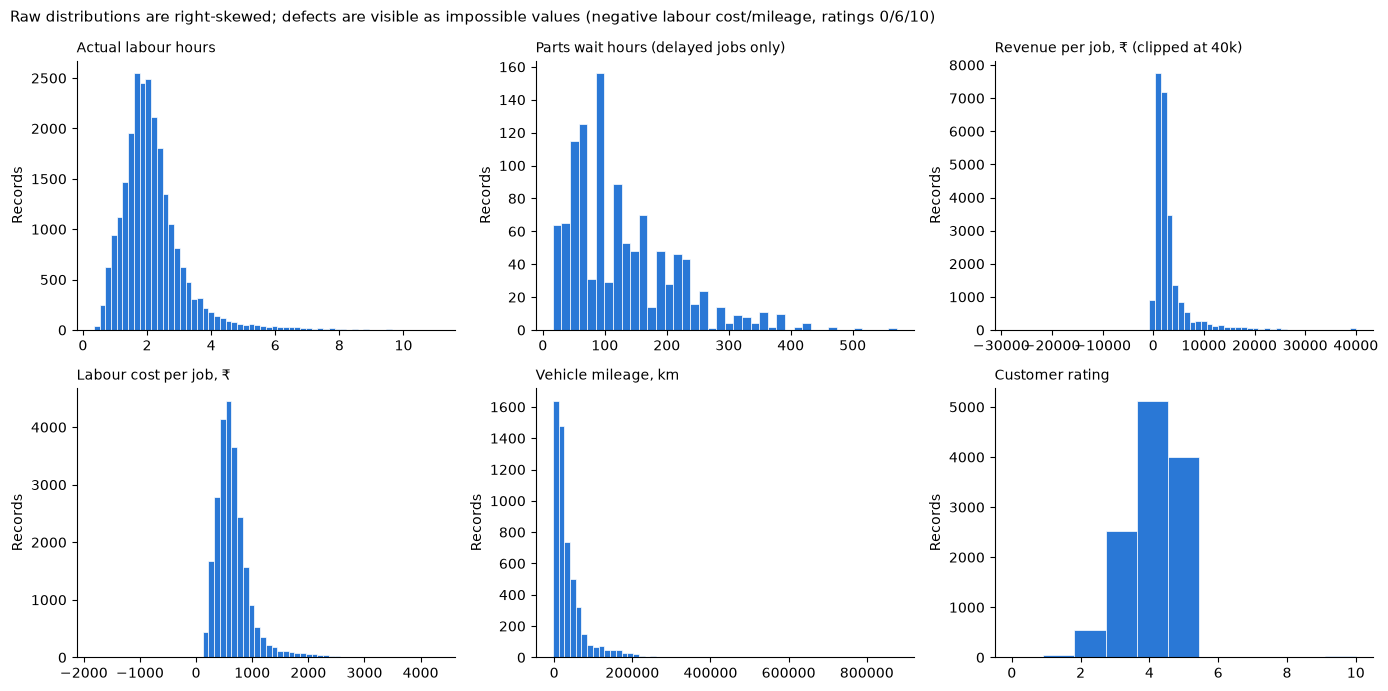

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
specs = [(wo["actual_hours"], "Actual labour hours", 60), (wo["parts_wait_hours"][wo["parts_wait_hours"] > 0], "Parts wait hours (delayed jobs only)", 40),
         (fin["revenue"].clip(upper=40000), "Revenue per job, ₹ (clipped at 40k)", 60),
         (fin["labor_cost"], "Labour cost per job, ₹", 60), (raw["vehicles"]["mileage_km"], "Vehicle mileage, km", 60),
         (raw["feedback"]["rating"].dropna(), "Customer rating", 11)]
for ax, (s, title, bins) in zip(axes.flat, specs):
    ax.hist(s, bins=bins, color="#2a78d6", edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_ylabel("Records")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Raw distributions are right-skewed; defects are visible as impossible values (negative labour cost/mileage, ratings 0/6/10)",
             fontsize=11, x=0.01, ha="left")
fig.tight_layout()
plt.show()

**What the raw profile tells us**

* Labour hours and revenue are right-skewed, as expected in a workshop where most jobs are short periodic
  services and a minority are long repairs.
* Parts waits, when they happen, are measured in **days** (tens to hundreds of hours) - the first hint that
  stock-outs drive the long tail of turnaround.
* Impossible values are visible even before formal validation: negative labour cost and revenue, negative or
  implausibly large mileage, and ratings of 0, 6 and 10 on a 1-5 scale.

In [12]:
issues = pd.DataFrame([
    ("financials", "negative revenue or labour cost", int(((fin["revenue"] < 0) | (fin["labor_cost"] < 0)).sum())),
    ("financials", "revenue > ₹1 lakh on a single job", int((fin["revenue"] > 100_000).sum())),
    ("feedback", "rating outside 1-5", int((~raw["feedback"]["rating"].dropna().between(1, 5)).sum())),
    ("vehicles", "negative mileage", int((raw["vehicles"]["mileage_km"] < 0).sum())),
    ("vehicles", "mileage > 300,000 km", int((raw["vehicles"]["mileage_km"] > 300_000).sum())),
    ("work_orders", "missing technician_id", int(wo["technician_id"].isna().sum())),
    ("part_usage", "quantity <= 0", int((raw["part_usage"]["quantity"] <= 0).sum())),
], columns=["table", "quick check", "rows"])
issues

,table,quick check,rows
0,financials,negative revenue or labour cost,48
1,financials,revenue > ₹1 lakh on a single job,19
2,feedback,rating outside 1-5,49
3,vehicles,negative mileage,5
4,vehicles,"mileage > 300,000 km",10
5,work_orders,missing technician_id,48
6,part_usage,quantity <= 0,92


## Summary

* The dataset is a reproducible, seed-driven simulation of an 8-centre EV two-wheeler service network
  (Jan 2025 - Sep 2026) with **24,213 raw work orders** and **26,955 raw appointments**.
* Operational behaviour - queueing under load, parts stock-outs, skill effects, booking-lead-time cancellations -
  emerges from simulation mechanics, so the later analysis has genuine signal to discover (and genuine noise).
* A documented set of data-entry defects is injected; **notebook 02** detects, repairs and reconciles them
  against the manifest.